# Phishing Website Detection — Machine Learning Project

**Dataset:** UCI Phishing Websites (ID: 327) | **Instances:** 11,055 | **Features:** 30

The goal here is to build a classifier that can tell whether a website is phishing or legitimate based on features extracted from the URL and page content. All features are already encoded as -1, 0, or 1 — so a lot of the usual preprocessing headaches are already handled for us.

---
**Table of Contents**
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Preprocessing & Data Cleaning](#2-preprocessing--data-cleaning)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Train-Test Split & Feature Scaling](#4-train-test-split--feature-scaling)
5. [Model Training & Evaluation](#5-model-training--evaluation)
6. [Confusion Matrices](#6-confusion-matrices)
7. [ROC Curves](#7-roc-curves)
8. [Model Comparison](#8-model-comparison)
9. [Hyperparameter Tuning](#9-hyperparameter-tuning)
10. [Tuned Model Comparison](#10-tuned-model-comparison)
11. [Save Best Model](#11-save-best-model)

## 1. Setup & Data Loading

First things first — install the `ucimlrepo` package so we can pull the dataset directly from the UCI repository. Everything else (sklearn, pandas, etc.) should already be in Colab.

In [2]:
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn joblib --quiet

### 1.1 Import Libraries & Load Dataset

Loading all the libraries we'll need up front. Using `warnings.filterwarnings('ignore')` because sklearn throws a lot of convergence warnings that aren't really useful here.

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')  # sklearn throws a lot of convergence warnings — not useful for us right now

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# pull the dataset directly from UCI — no manual download needed
phishing_websites = fetch_ucirepo(id=327)
X = phishing_websites.data.features
y = phishing_websites.data.targets

print('Dataset shape:', X.shape)
print('Target shape:', y.shape)
print('Features:', list(X.columns))

Dataset shape: (11055, 30)
Target shape: (11055, 1)
Features: ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registration_length', 'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor', 'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url', 'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report']


## 2. Preprocessing & Data Cleaning

Before modeling, we need to check the basics: missing values, duplicate rows, and class balance. Since the dataset description says all features are already encoded as integers (-1, 0, 1), we won't need to do any label encoding or one-hot encoding — which is pretty convenient.

> **Note:** We're merging X and y into one dataframe just to make it easier to inspect everything together.

In [4]:
# merge features and target into one dataframe — easier to inspect everything at once
df = pd.concat([X, y], axis=1)

print('=== Dataset Info ===')
print(df.info())  # checking dtypes and non-null counts
print('\n=== Missing Values ===')
print(df.isnull().sum())  # the dataset description said no missing values — let's confirm
print('\n=== Duplicates ===')
print('Duplicate rows:', df.duplicated().sum())  # this is surprisingly high — worth removing

df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

# class distribution — important to check before modeling
print('\n=== Target Distribution ===')
print(df['result'].value_counts())
print('\nClass balance (%):')
print(df['result'].value_counts(normalize=True) * 100)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-nu

## 3. Exploratory Data Analysis (EDA)

Now let's actually look at the data before throwing it at models. EDA helps us understand:
- Whether the classes are balanced (important for choosing the right metrics)
- How the features are distributed
- Which features might actually be useful for predicting phishing

We'll generate four plots:
1. Class distribution bar chart
2. Feature correlation heatmap
3. Individual feature value distributions
4. Feature correlation with the target variable

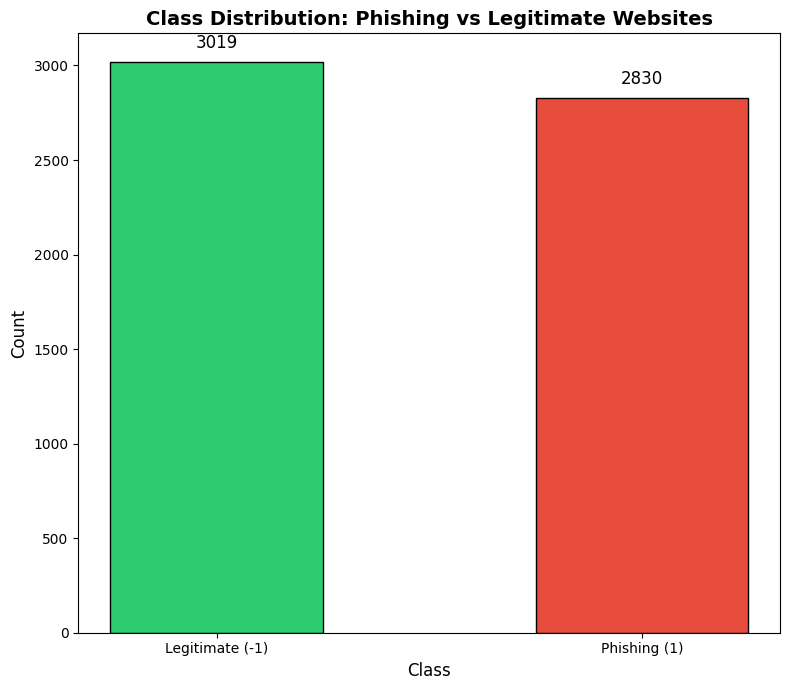

In [8]:
# --- Plot 1: Class distribution ---
plt.figure(figsize=(8, 7))
class_counts = df['result'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Legitimate (-1)', 'Phishing (1)'],
               [class_counts.get(-1, 0), class_counts.get(1, 0)],
               color=colors, edgecolor='black', width=0.5)
# annotating bars with exact counts
for bar, count in zip(bars, [class_counts.get(-1, 0), class_counts.get(1, 0)]):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
             f'{count}', ha='center', va='bottom', fontsize=12)
plt.title('Class Distribution: Phishing vs Legitimate Websites', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

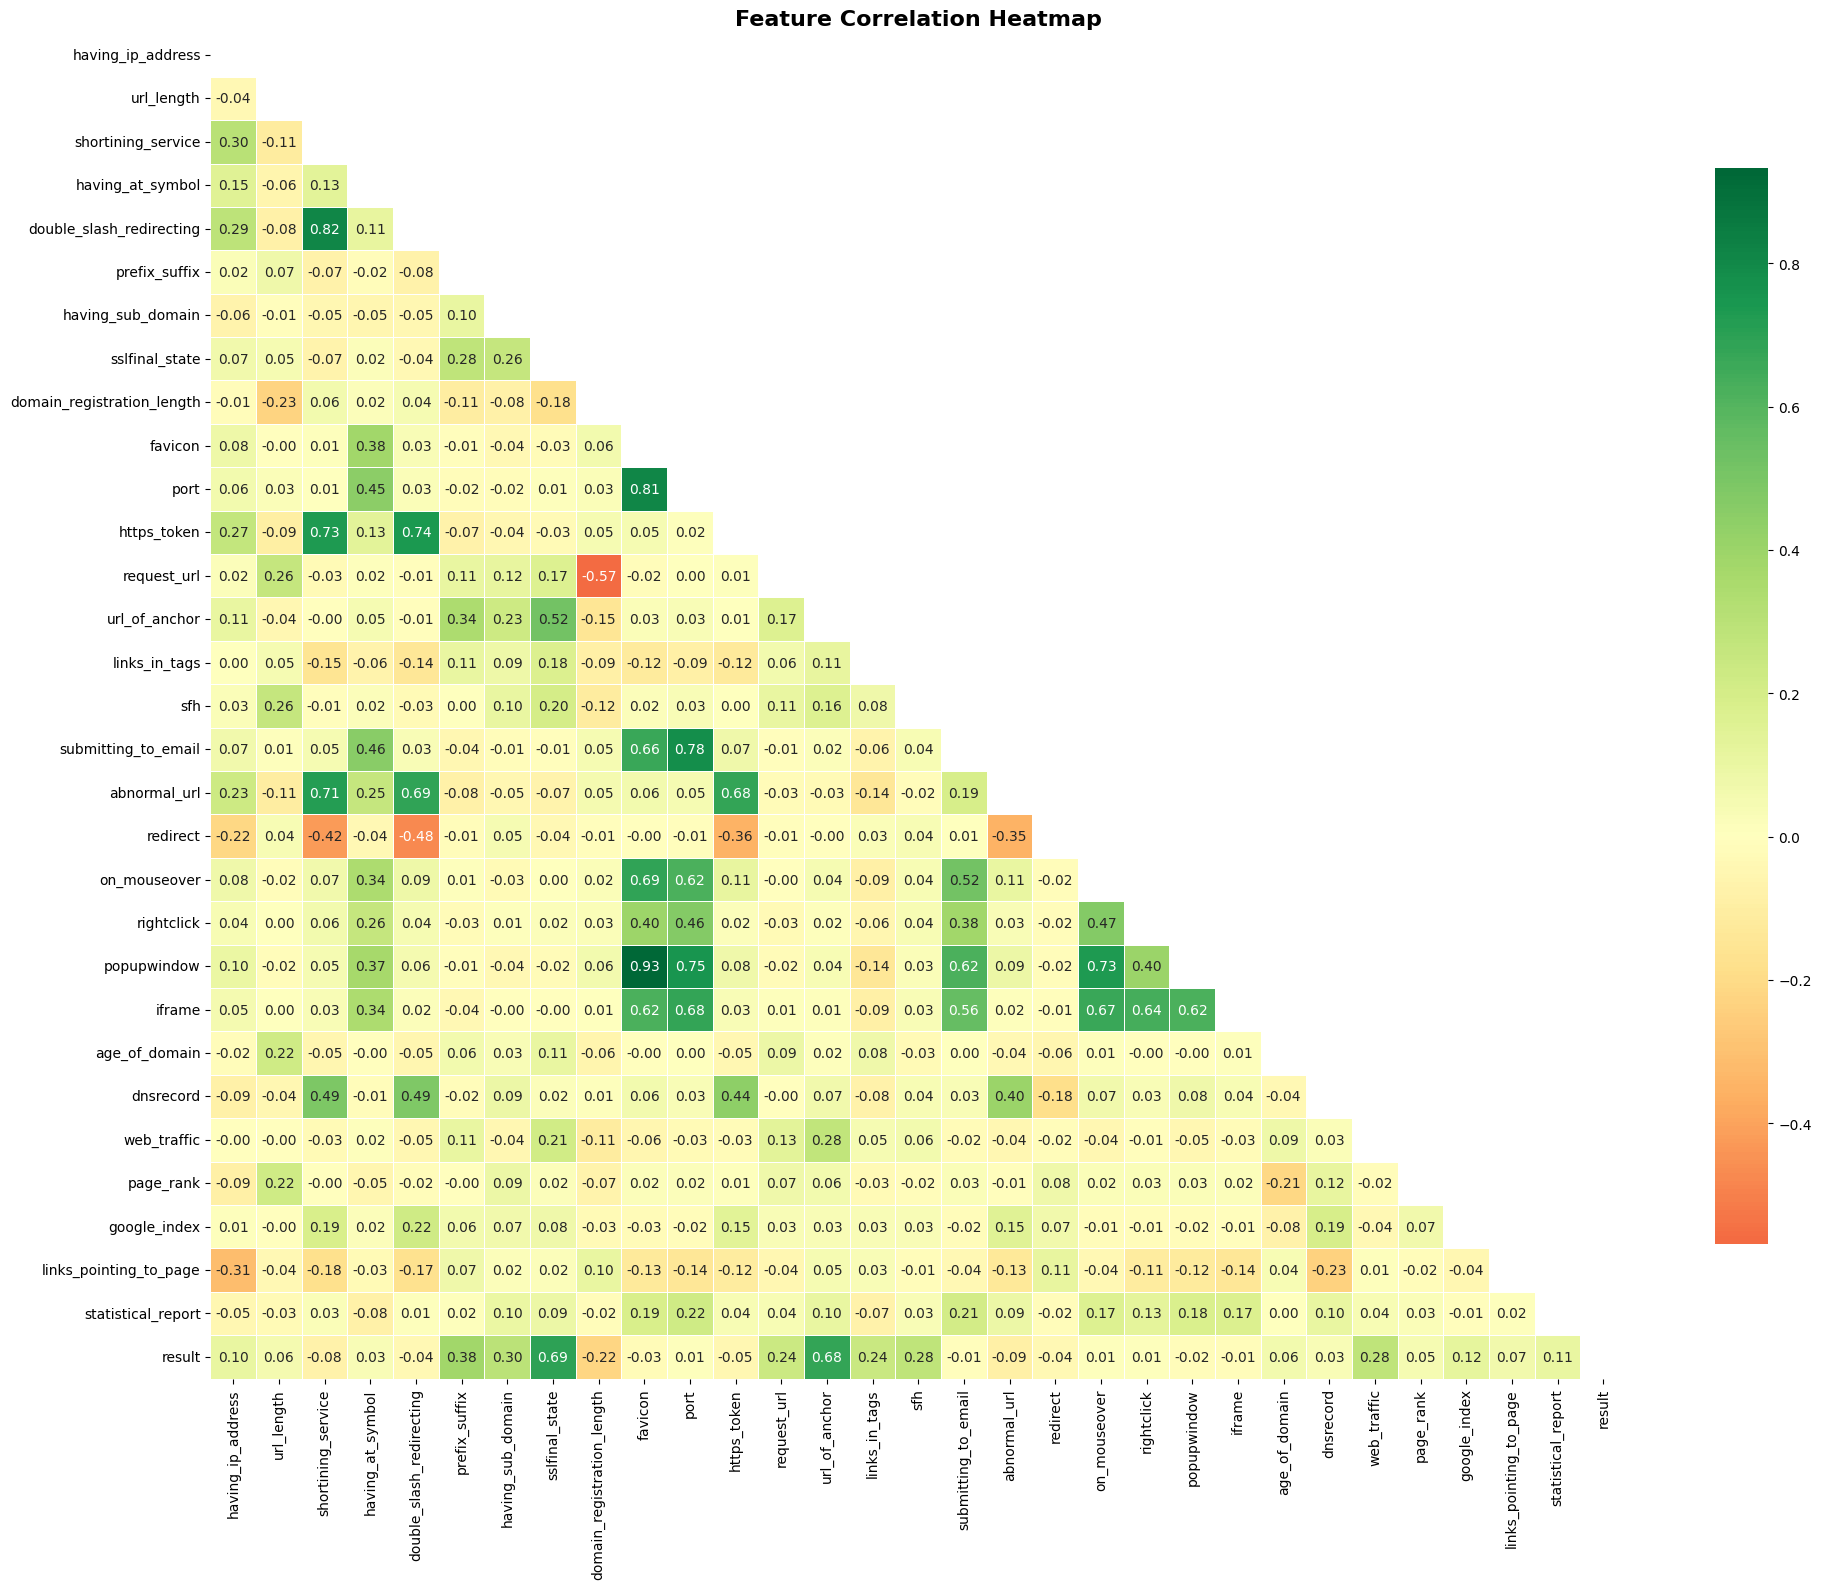

In [11]:
# --- Plot 2: Correlation heatmap ---
# masking the upper triangle so we don't see duplicate pairs
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

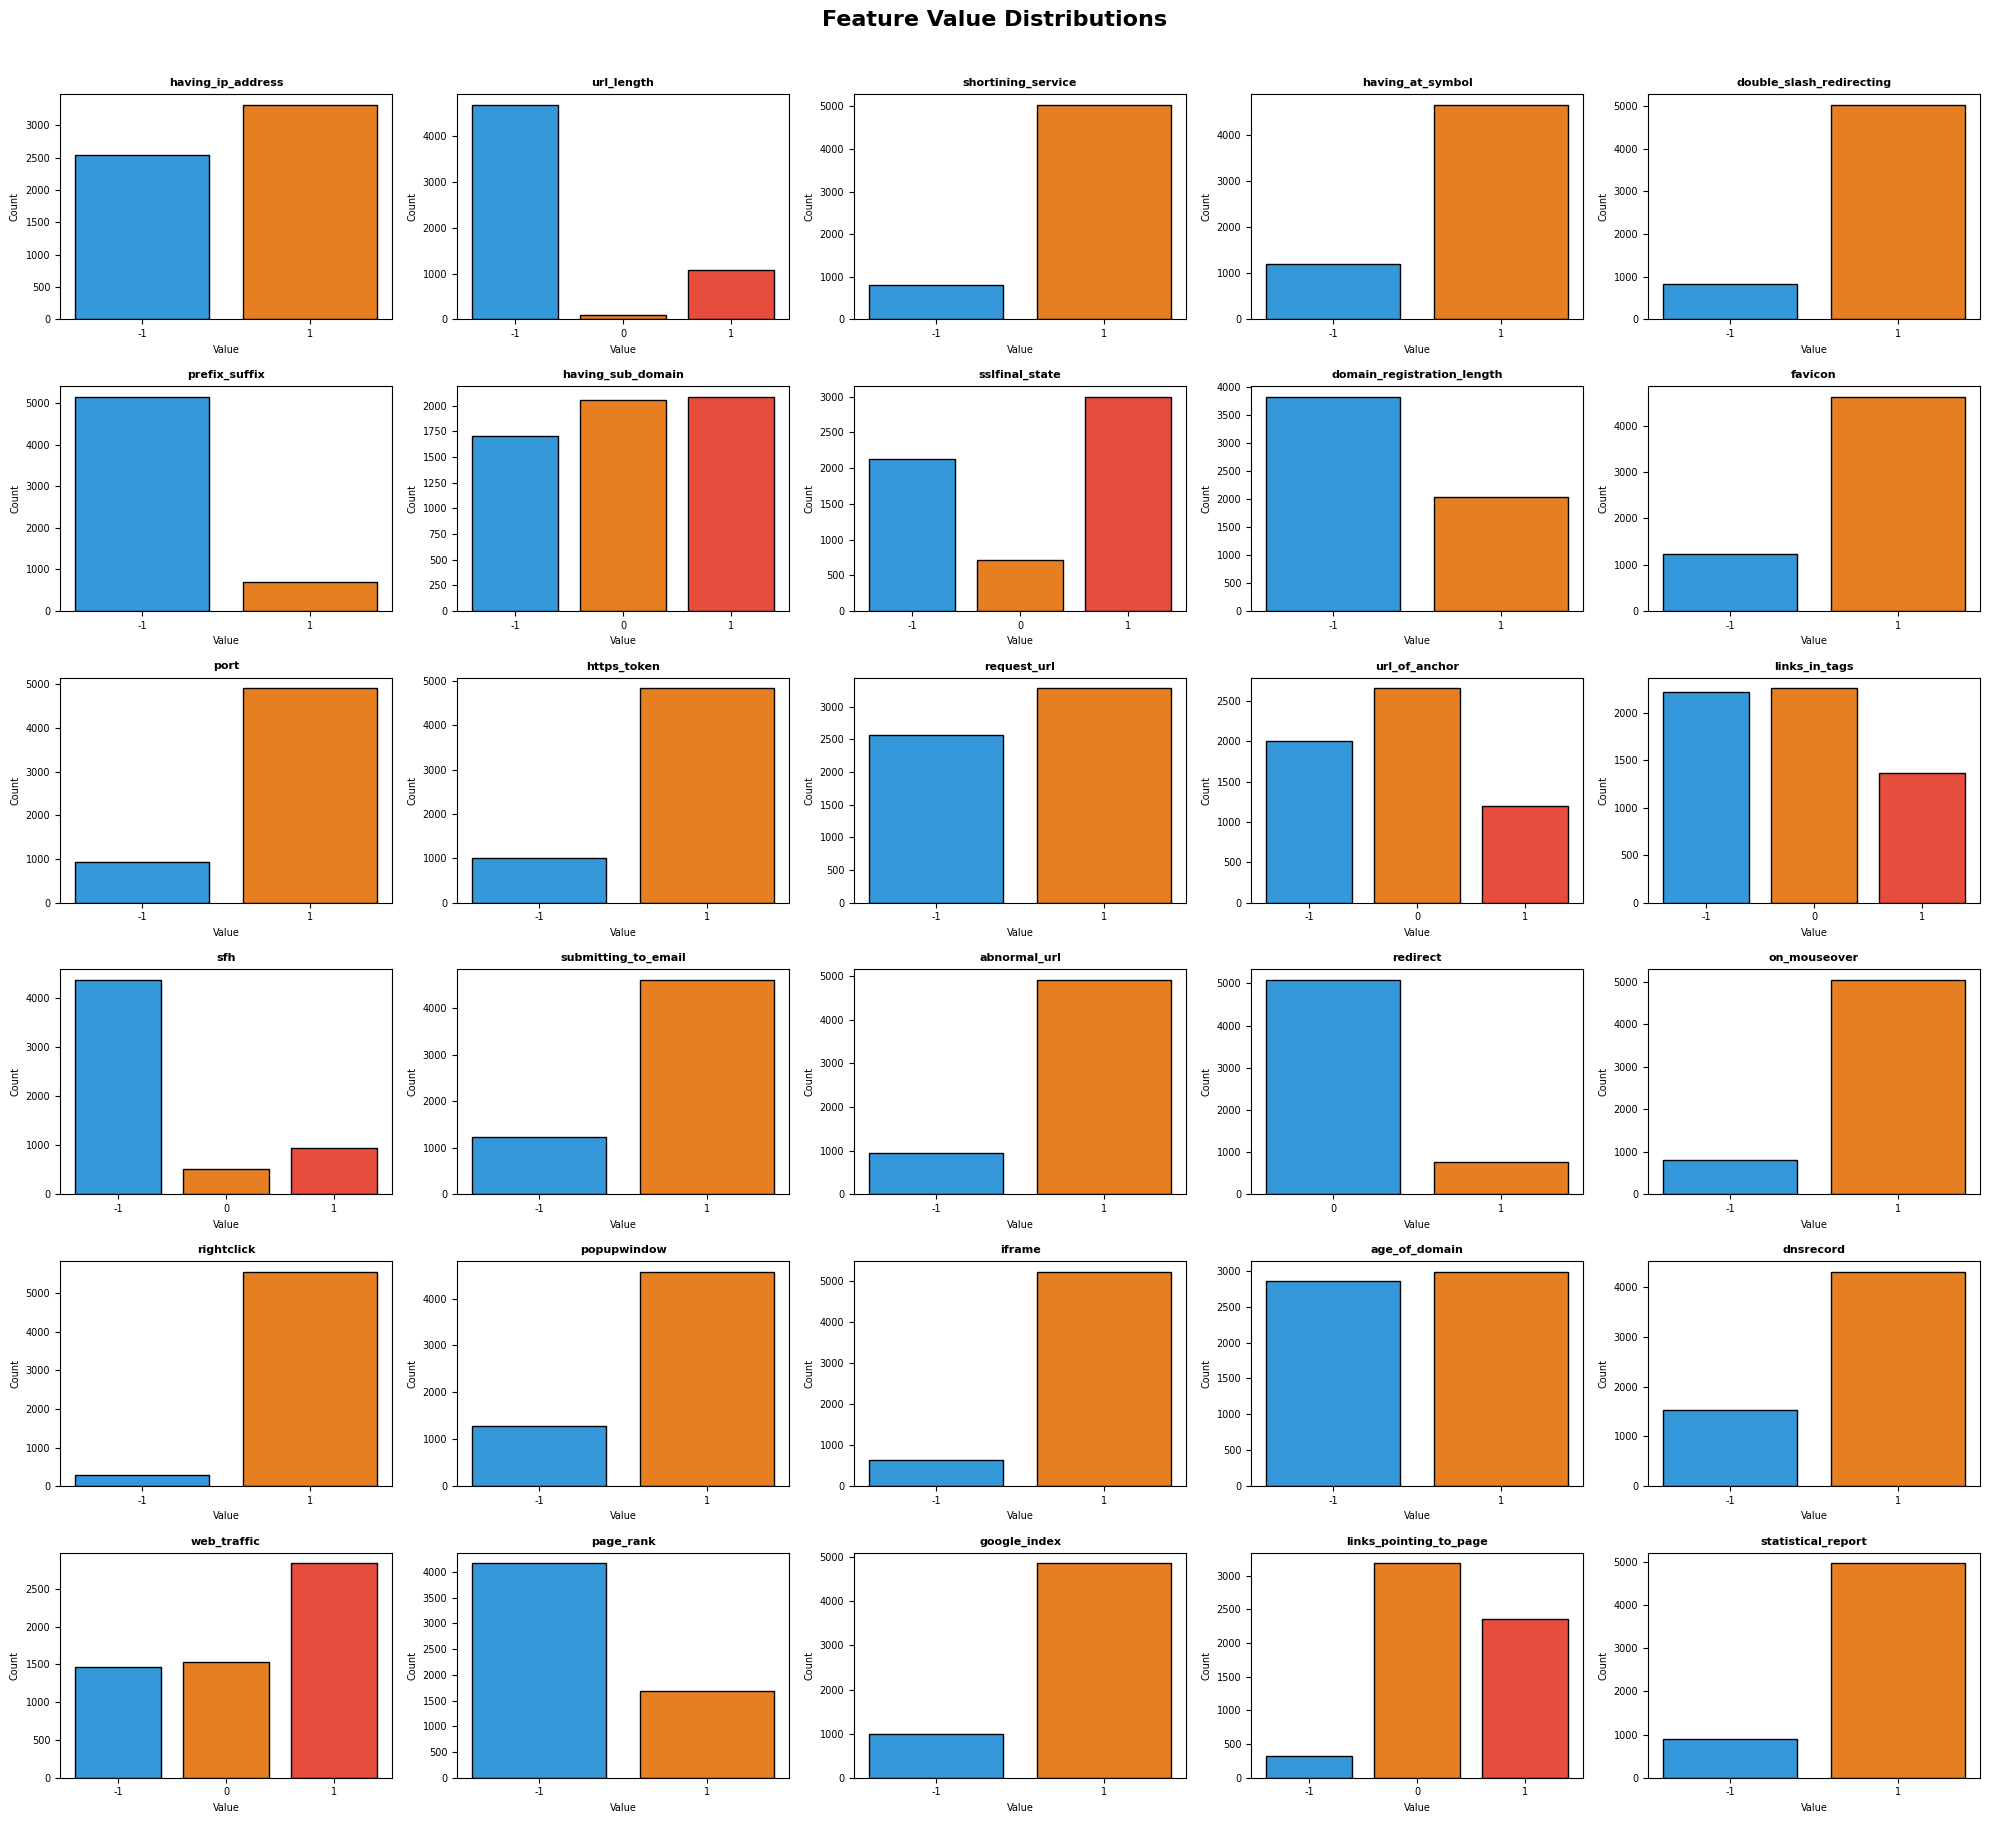

In [12]:
# --- Plot 3: Individual feature distributions ---
# since all features are -1/0/1, bar charts make more sense than histograms
feature_cols = X.columns.tolist()
n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    vals = df[col].value_counts().sort_index()
    axes[i].bar(vals.index.astype(str), vals.values, color=['#3498db', '#e67e22', '#e74c3c'], edgecolor='black')
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Count', fontsize=7)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Value Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

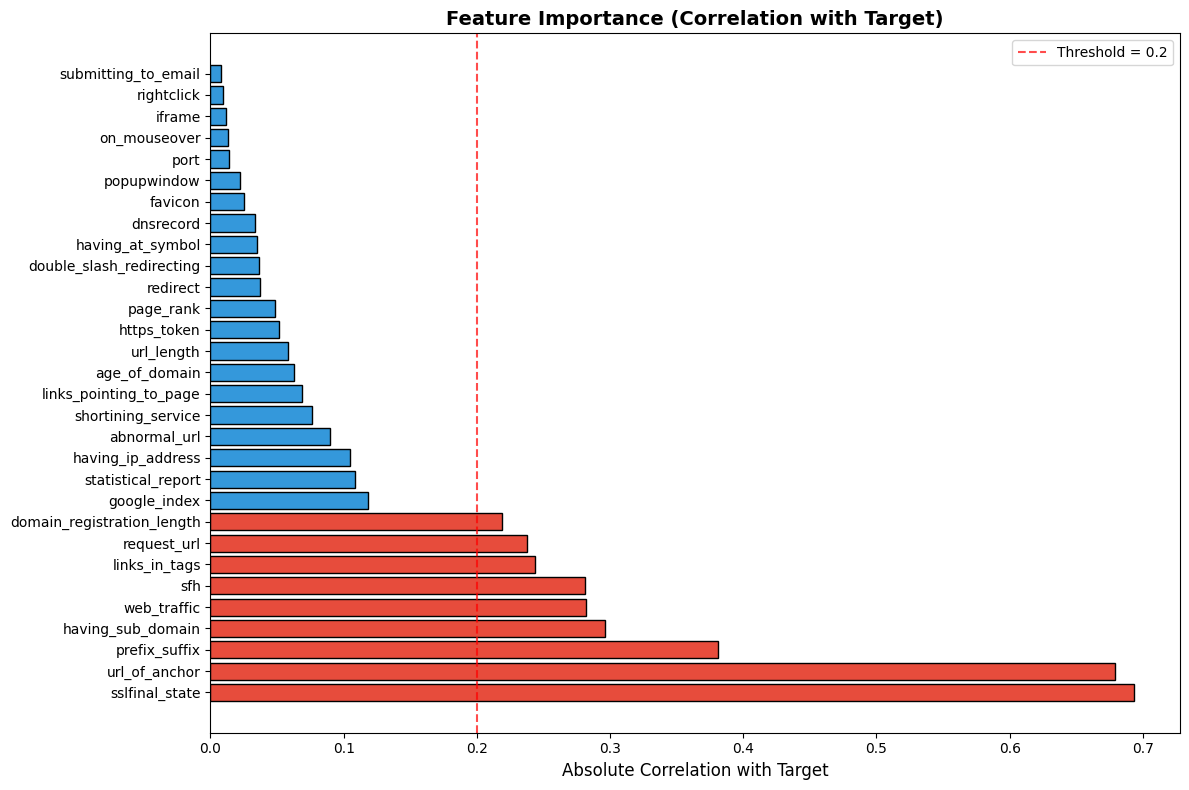

Top 10 features correlated with target:
sslfinal_state                0.693228
url_of_anchor                 0.679125
prefix_suffix                 0.381134
having_sub_domain             0.296214
web_traffic                   0.281709
sfh                           0.281131
links_in_tags                 0.243864
request_url                   0.237778
domain_registration_length    0.218623
google_index                  0.118217
dtype: float64


In [13]:
# --- Plot 4: Feature correlation with target ---
# using absolute correlation since we care about the strength, not direction
X_df = df.drop('result', axis=1)
y_series = df['result']
corr_with_target = X_df.corrwith(y_series).abs().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
colors_bar = ['#e74c3c' if v > 0.2 else '#3498db' for v in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='black')
plt.axvline(x=0.2, color='red', linestyle='--', alpha=0.7, label='Threshold = 0.2')
plt.xlabel('Absolute Correlation with Target', fontsize=12)
plt.title('Feature Importance (Correlation with Target)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('feature_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features correlated with target:')
print(corr_with_target.head(10))

## 4. Train-Test Split & Feature Scaling

Splitting the data 80/20 with `stratify=y` — this makes sure both the training and test sets have roughly the same class proportions, which matters especially since our classes are close but not exactly equal after removing duplicates.

We're also applying `StandardScaler` here. Not all models need it — Decision Tree and Random Forest are scale-invariant — but **KNN and SVM** are sensitive to feature magnitudes, so we scale for those. We fit the scaler only on training data to avoid data leakage.

In [14]:
X_clean = df.drop('result', axis=1)
y_clean = df['result']

# stratify=y_clean ensures class proportions are preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# StandardScaler is needed for KNN and SVM — they're distance-based and sensitive to scale
# Important: fit only on training data, then transform both — avoids data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print('\nTraining class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

Training set size: (4679, 30)
Test set size: (1170, 30)

Training class distribution:
result
-1    2415
 1    2264
Name: count, dtype: int64

Test class distribution:
result
-1    604
 1    566
Name: count, dtype: int64


## 5. Model Training & Evaluation

We're testing five classifiers (plus Logistic Regression as a bonus baseline):

| Model | Needs Scaling? | Notes |
|---|---|---|
| Decision Tree | No | Simple, interpretable baseline |
| Random Forest | No | Ensemble — usually hard to beat |
| KNN | **Yes** | Distance-based, needs scaled features |
| Naive Bayes | No | Assumes feature independence |
| SVM | **Yes** | Powerful but slow on large datasets |
| Logistic Regression | **Yes** | Linear baseline for comparison |

The `evaluate_model()` function handles training, prediction, and metric calculation all in one place. We're using F1-score as the main metric since we care about both false positives (blocking legit sites) and false negatives (missing phishing sites).

> **Heads up:** SVM and KNN will take noticeably longer to train than the tree-based models.

In [15]:
# reusable function so we don't repeat the same metric calculations 6 times
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # SVM with decision_function doesn't return probabilities by default,
    # so we normalize scores to [0,1] as a workaround
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, pos_label=1)
    rec = recall_score(y_te, y_pred, pos_label=1)
    f1 = f1_score(y_te, y_pred, pos_label=1)
    roc = roc_auc_score(y_te, y_prob)
    # 5-fold CV gives a better sense of how stable the model is
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f'\n{"="*50}')
    print(f'Model: {name}')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'ROC-AUC:   {roc:.4f}')
    print(f'CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred))
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc,
        'CV Accuracy': cv_scores.mean(),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model_obj': model
    }

results = []

# Decision Tree — no scaling needed, tree splits are scale-invariant
dt = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model('Decision Tree', dt, X_train, X_test, y_train, y_test))

# Random Forest — basically a bunch of decision trees voting together
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test))

# KNN — uses scaled features since it calculates distances between points
knn = KNeighborsClassifier()
results.append(evaluate_model('KNN', knn, X_train_scaled, X_test_scaled, y_train, y_test))

# Naive Bayes — assumes features are independent, which is a strong assumption here
nb_model = GaussianNB()
results.append(evaluate_model('Naive Bayes', nb_model, X_train, X_test, y_train, y_test))

# SVM — slow but usually strong; needs scaled input
svm = SVC(probability=True, random_state=42)  # probability=True so we can get predict_proba
results.append(evaluate_model('SVM', svm, X_train_scaled, X_test_scaled, y_train, y_test))

# Logistic Regression — linear model, good as a baseline comparison
lr = LogisticRegression(random_state=42)
results.append(evaluate_model('Logistic Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test))


Model: Decision Tree
Accuracy:  0.9171
Precision: 0.9180
Recall:    0.9099
F1-Score:  0.9139
ROC-AUC:   0.9219
CV Accuracy: 0.9226 (+/- 0.0159)

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.92      0.92       604
           1       0.92      0.91      0.91       566

    accuracy                           0.92      1170
   macro avg       0.92      0.92      0.92      1170
weighted avg       0.92      0.92      0.92      1170


Model: Random Forest
Accuracy:  0.9419
Precision: 0.9368
Recall:    0.9435
F1-Score:  0.9401
ROC-AUC:   0.9881
CV Accuracy: 0.9432 (+/- 0.0120)

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.94      0.94       604
           1       0.94      0.94      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170


Model: 

## 6. Confusion Matrices

Confusion matrices give a more detailed picture of where each model is making mistakes. For phishing detection specifically:
- **False Negatives** (predicted Legitimate, actually Phishing) = more dangerous — we missed a threat
- **False Positives** (predicted Phishing, actually Legitimate) = annoying but less harmful — we blocked a safe site

Ideally we want high values on the diagonal and low values off it.

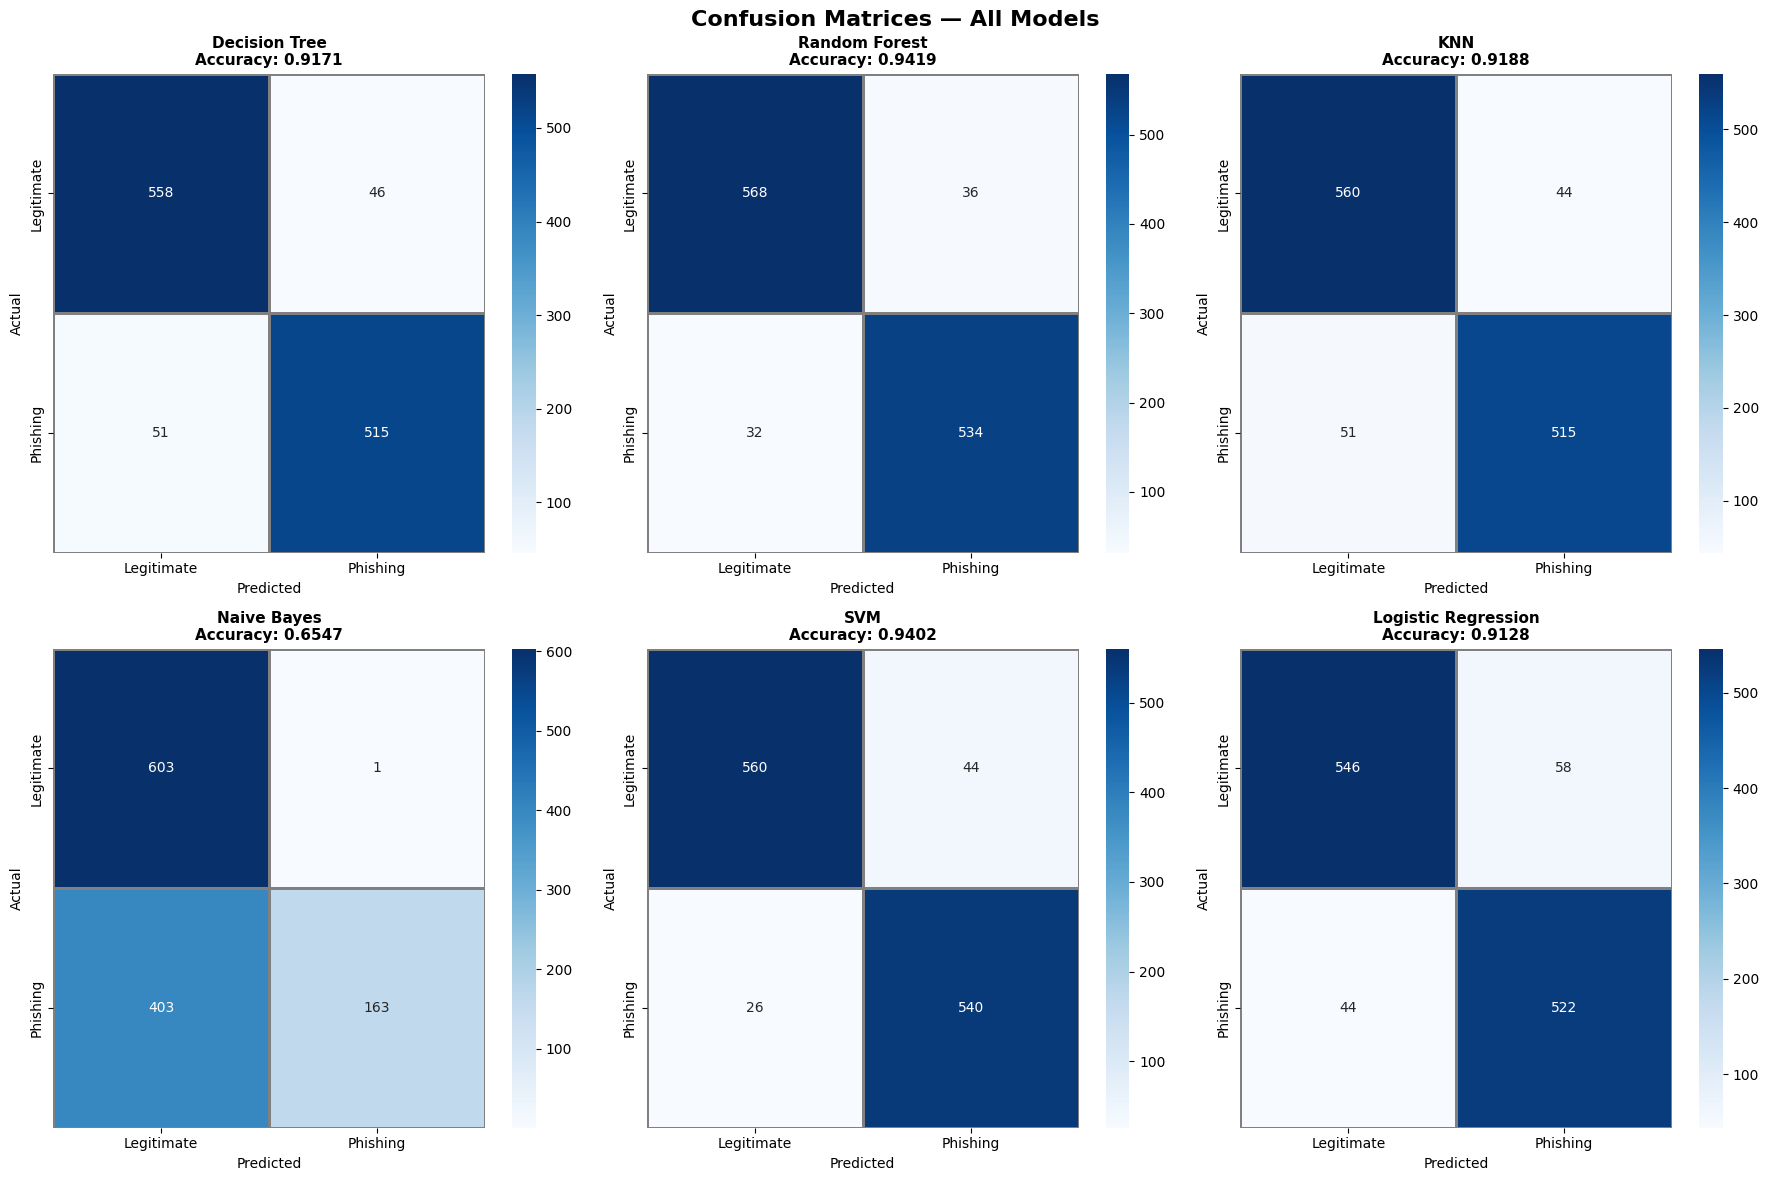

In [16]:
# plotting all confusion matrices side-by-side for easy comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, res in enumerate(results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'],
                linewidths=1, linecolor='gray')
    axes[i].set_title(f"{res['Model']}\nAccuracy: {res['Accuracy']:.4f}",
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)
plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ROC Curves

ROC curves show the tradeoff between true positive rate and false positive rate across different classification thresholds. A higher AUC means the model is better at ranking phishing sites above legitimate ones — even if the exact cutoff isn't set yet.

This is useful because it's threshold-independent, so it gives a sense of the model's overall discriminative ability regardless of where we draw the line.

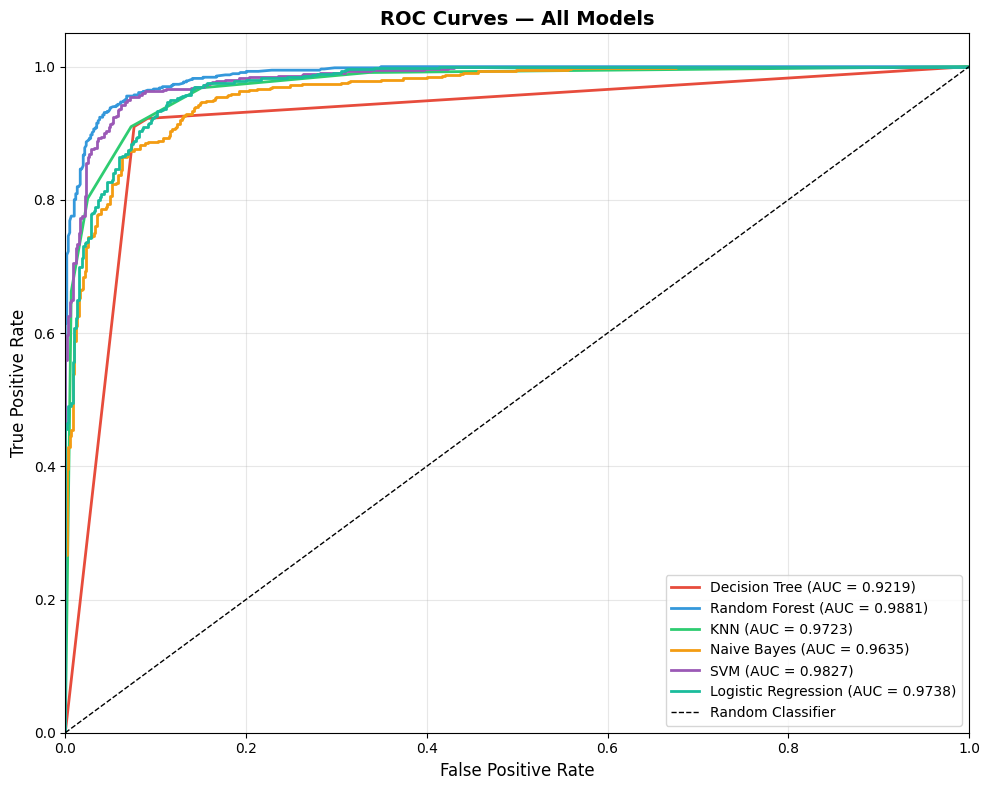

In [17]:
plt.figure(figsize=(10, 8))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for res, color in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'], pos_label=1)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{res['Model']} (AUC = {res['ROC-AUC']:.4f})")

# the dashed line represents a random classifier — anything above this is useful
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Comparison

Let's pull all the metrics together into one table to make it easier to compare. We'll sort by F1-score since that balances precision and recall — which feels like the right priority for a security use case.

We're also plotting a grouped bar chart so the differences are easier to see visually.


=== MODEL COMPARISON TABLE ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy
      Random Forest    0.9419     0.9368  0.9435    0.9401   0.9881       0.9432
                SVM    0.9402     0.9247  0.9541    0.9391   0.9827       0.9380
                KNN    0.9188     0.9213  0.9099    0.9156   0.9723       0.9166
      Decision Tree    0.9171     0.9180  0.9099    0.9139   0.9219       0.9226
Logistic Regression    0.9128     0.9000  0.9223    0.9110   0.9738       0.9196
        Naive Bayes    0.6547     0.9939  0.2880    0.4466   0.9635       0.6546


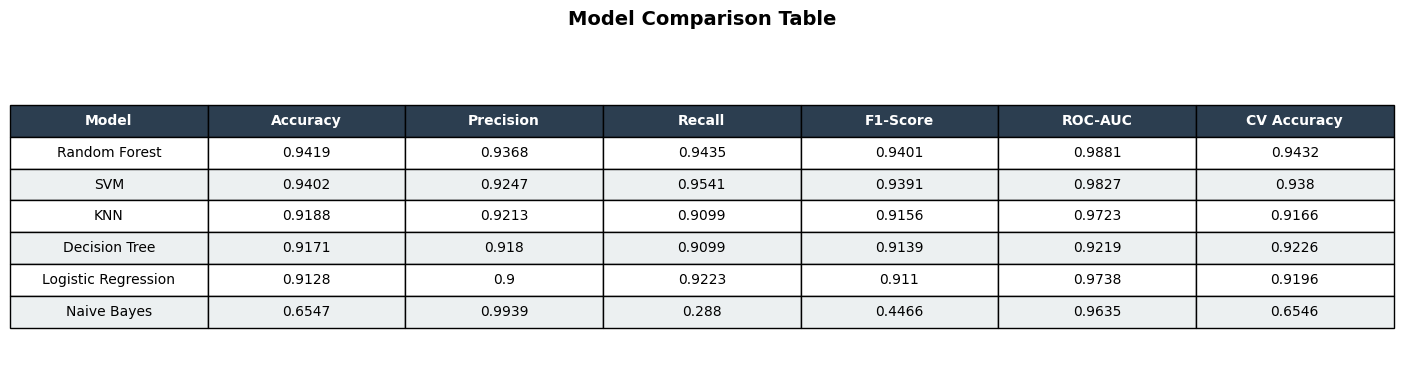

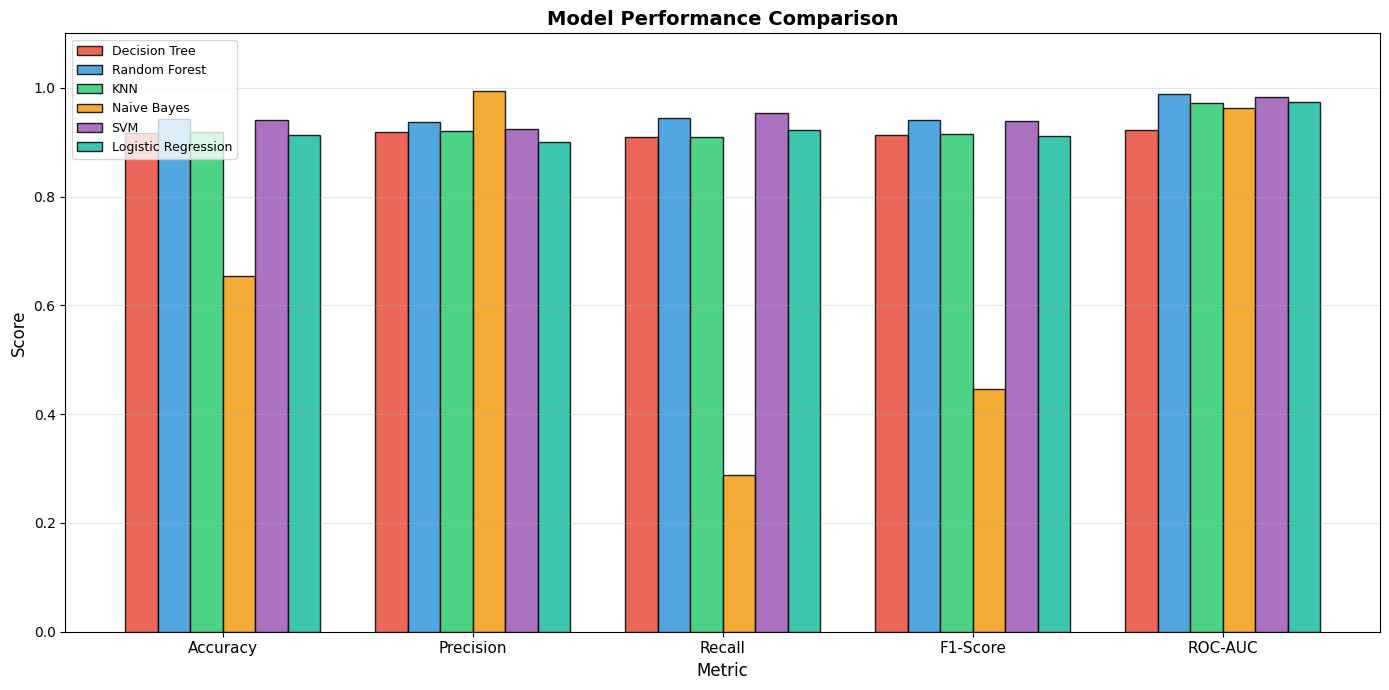

In [18]:
# collecting all metrics into one clean table
comparison_data = []
for res in results:
    comparison_data.append({
        'Model': res['Model'],
        'Accuracy': round(res['Accuracy'], 4),
        'Precision': round(res['Precision'], 4),
        'Recall': round(res['Recall'], 4),
        'F1-Score': round(res['F1-Score'], 4),
        'ROC-AUC': round(res['ROC-AUC'], 4),
        'CV Accuracy': round(res['CV Accuracy'], 4)
    })

# sorting by F1 — balances precision and recall, which is what we care about here
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string(index=False))

# render as a nice table in the notebook
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(cellText=comparison_df.values,
                 colLabels=comparison_df.columns,
                 cellLoc='center', loc='center',
                 colColours=['#2c3e50'] * len(comparison_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('#ffffff')
plt.title('Model Comparison Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

# grouped bar chart — easier to compare across models visually
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.13
fig, ax = plt.subplots(figsize=(14, 7))
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for i, (res, color) in enumerate(zip(comparison_data, bar_colors)):
    vals = [res[m] for m in metrics]
    offset = (i - len(comparison_data)/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=res['Model'], color=color, alpha=0.85, edgecolor='black')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Hyperparameter Tuning

The default hyperparameters are rarely optimal. We're using `GridSearchCV` with 5-fold stratified cross-validation to search over a range of hyperparameter combinations for each model.

We're optimizing for **F1-score** (not accuracy) since that's what we actually care about.

> **Fair warning:** This cell takes a while to run — especially KNN and SVM. Grab a coffee.

| Model | Key Hyperparameters Being Tuned |
|---|---|
| Decision Tree | max_depth, min_samples_split, criterion |
| Random Forest | n_estimators, max_depth, min_samples_split |
| KNN | n_neighbors, weights, metric |
| Naive Bayes | var_smoothing |
| SVM | C, kernel, gamma |

In [26]:
best_base_model_name = comparison_df.iloc[0]['Model']
print(f'Best base model: {best_base_model_name}')
print('Running hyperparameter tuning...')

# StratifiedKFold keeps class balance in each fold — important for slightly imbalanced data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# each model has its own parameter grid and uses the right version of training data
param_grids = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 15, None],      # None = fully grown tree
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        },
        'X_train': X_train, 'X_test': X_test
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],           # more trees = better but slower
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        },
        'X_train': X_train, 'X_test': X_test
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],         # odd numbers avoid ties
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'X_train': X_train_scaled, 'X_test': X_test_scaled
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},  # smoothing handles zero-variance features
        'X_train': X_train, 'X_test': X_test
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],                    # regularization strength
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        },
        'X_train': X_train_scaled, 'X_test': X_test_scaled
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['liblinear', 'lbfgs']
        },
        'X_train': X_train_scaled, 'X_test': X_test_scaled
    }
}

tuned_results = []
best_overall_model = None
best_overall_score = 0
best_overall_name = ''

for name, cfg in param_grids.items():
    print(f'Tuning {name}...')
    # n_jobs=-1 uses all CPU cores — speeds things up significantly
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv,
                      scoring='f1', n_jobs=-1, verbose=0)
    gs.fit(cfg['X_train'], y_train)
    best_model = gs.best_estimator_
    y_pred = best_model.predict(cfg['X_test'])
    if hasattr(best_model, 'predict_proba'):
        y_prob = best_model.predict_proba(cfg['X_test'])[:, 1]
    else:
        # For models like SVC with kernel='linear' that might not have predict_proba by default
        # we normalize decision_function scores to [0,1] for ROC-AUC calculation.
        y_prob = best_model.decision_function(cfg['X_test'])
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    tuned_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4),
        'model_obj': best_model,
        'X_train': cfg['X_train'],
        'X_test': cfg['X_test']
    })
    print(f'  Best params: {gs.best_params_}')
    print(f'  F1: {f1:.4f} | Accuracy: {acc:.4f} | ROC-AUC: {roc:.4f}\n')
    if f1 > best_overall_score:
        best_overall_score = f1
        best_overall_model = best_model
        best_overall_name = name

print(f'\nBest overall model after tuning: {best_overall_name} (F1={best_overall_score:.4f})')

Best base model: Random Forest
Running hyperparameter tuning...
Tuning Decision Tree...
  Best params: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 5}
  F1: 0.9295 | Accuracy: 0.9333 | ROC-AUC: 0.9592

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  F1: 0.9401 | Accuracy: 0.9419 | ROC-AUC: 0.9881

Tuning KNN...
  Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
  F1: 0.9292 | Accuracy: 0.9316 | ROC-AUC: 0.9820

Tuning Naive Bayes...
  Best params: {'var_smoothing': 1e-06}
  F1: 0.6241 | Accuracy: 0.7333 | ROC-AUC: 0.9635

Tuning SVM...
  Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  F1: 0.9413 | Accuracy: 0.9427 | ROC-AUC: 0.9865

Tuning Logistic Regression...
  Best params: {'C': 0.1, 'solver': 'liblinear'}
  F1: 0.9110 | Accuracy: 0.9128 | ROC-AUC: 0.9735


Best overall model after tuning: SVM (F1=0.9413)


## 10. Tuned Model Comparison

Now let's compare all the tuned models and see if hyperparameter tuning actually helped. We'll also combine base vs. tuned results into one chart to make the improvement (or lack of it) visible.


=== TUNED MODEL COMPARISON ===
              Model  Accuracy  F1-Score  ROC-AUC
                SVM    0.9427    0.9413   0.9865
      Random Forest    0.9419    0.9401   0.9881
      Decision Tree    0.9333    0.9295   0.9592
                KNN    0.9316    0.9292   0.9820
Logistic Regression    0.9128    0.9110   0.9735
        Naive Bayes    0.7333    0.6241   0.9635


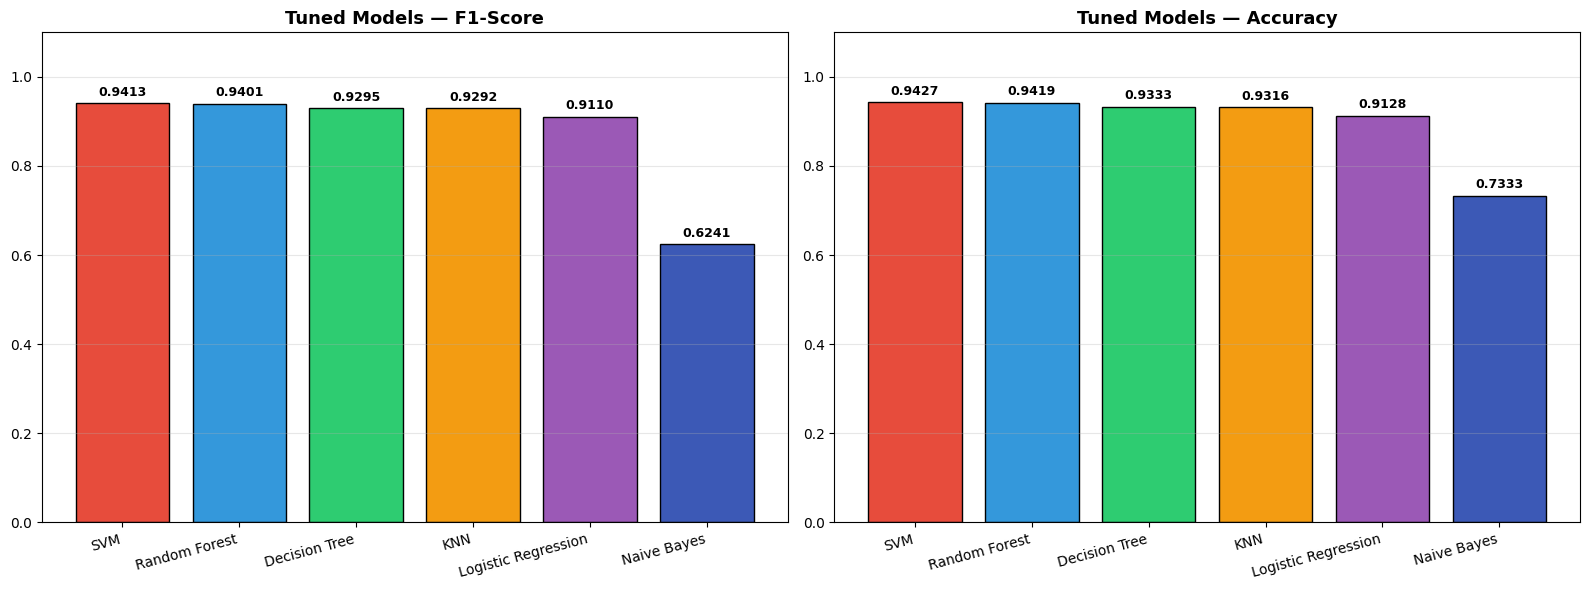

In [29]:
tuned_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'F1-Score': r['F1-Score'],
    'ROC-AUC': r['ROC-AUC']
} for r in tuned_results]).sort_values('F1-Score', ascending=False)

print('\n=== TUNED MODEL COMPARISON ===')
print(tuned_df.to_string(index=False))

# comparing tuned F1 and Accuracy side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models_names = tuned_df['Model'].tolist()
f1_scores = tuned_df['F1-Score'].tolist()
acc_scores = tuned_df['Accuracy'].tolist()
bar_c = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#3c59b6']
axes[0].bar(models_names, f1_scores, color=bar_c[:len(models_names)], edgecolor='black')
axes[0].set_title('Tuned Models — F1-Score', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(models_names, rotation=15, ha='right')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[0].patches, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].bar(models_names, acc_scores, color=bar_c[:len(models_names)], edgecolor='black')
axes[1].set_title('Tuned Models — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_xticklabels(models_names, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[1].patches, acc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('tuned_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

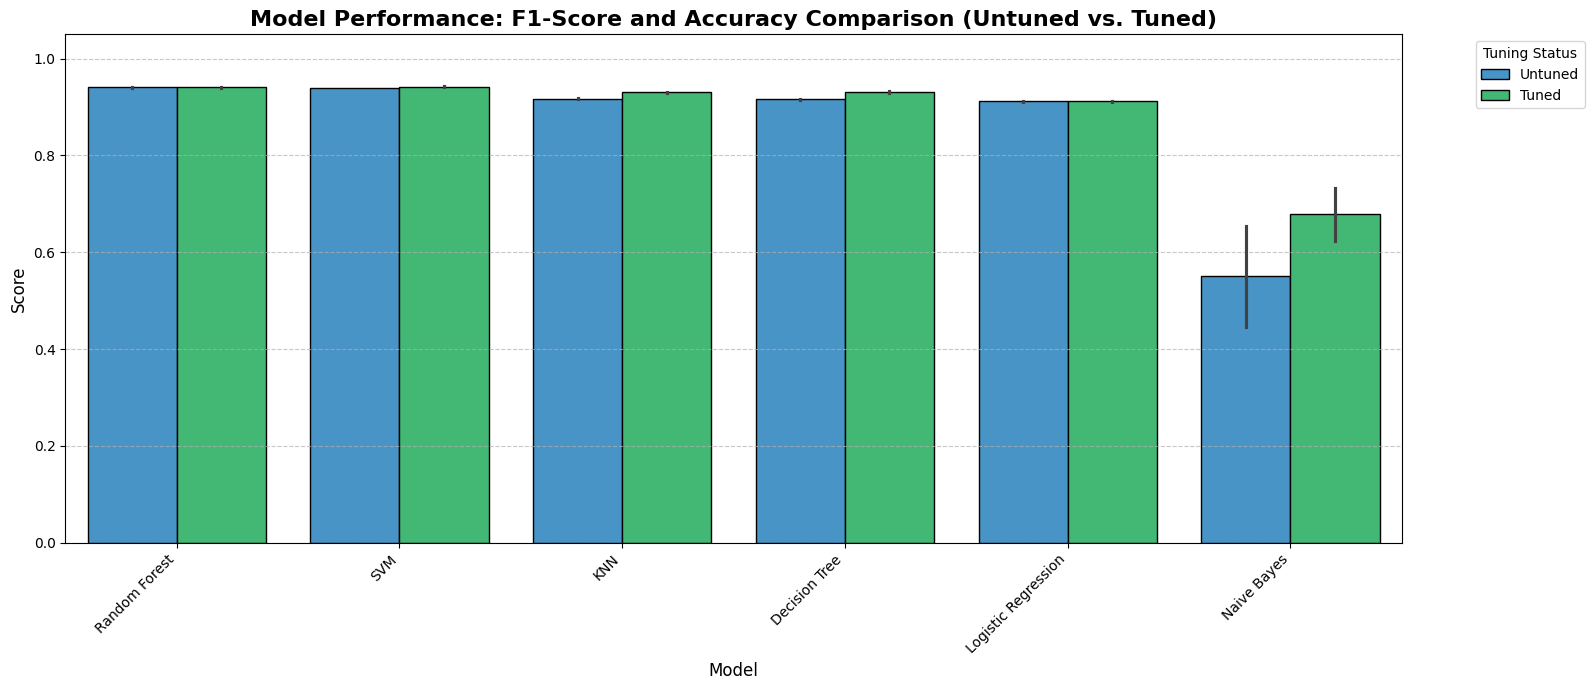

In [28]:
# Prepare data for plotting
# Extract relevant columns from comparison_df (untuned results)
untuned_results_for_plot = comparison_df[['Model', 'Accuracy', 'F1-Score']].copy()
untuned_results_for_plot['Tuning Status'] = 'Untuned'

# Extract relevant columns from tuned_df (tuned results)
tuned_results_for_plot = tuned_df[['Model', 'Accuracy', 'F1-Score']].copy()
tuned_results_for_plot['Tuning Status'] = 'Tuned'

# Combine untuned and tuned results
combined_results = pd.concat([untuned_results_for_plot, tuned_results_for_plot], ignore_index=True)

plot_df = combined_results.melt(id_vars=['Model', 'Tuning Status'], value_vars=['F1-Score', 'Accuracy'],
                                var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 7))

sns.barplot(data=plot_df, x='Model', y='Score', hue='Tuning Status',
            palette={'Untuned': '#3498db', 'Tuned': '#2ecc71'}, edgecolor='black')

plt.title('Model Performance: F1-Score and Accuracy Comparison (Untuned vs. Tuned)', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tuning Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_tuning_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Best Model

The best-performing model (by F1-score after tuning) gets saved to disk using `joblib`. We also save:
- `scaler.joblib` — so we can apply the same scaling to new inputs
- `model_info.joblib` — a small dict with the model name, whether it needs scaling, and the feature list

That last one is important for the Streamlit app — it needs to know whether to scale the input before passing it to the model.

Finally, we do a quick sanity check by reloading the saved model and running it on 5 test samples.

In [30]:
print(f'Saving best model: {best_overall_name}')
joblib.dump(best_overall_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

# saving whether this model needs scaling — the Streamlit app needs to know this
needs_scaling = best_overall_name in ['KNN', 'SVM']
model_info = {
    'model_name': best_overall_name,
    'needs_scaling': needs_scaling,
    'features': list(X_clean.columns),
    'f1_score': best_overall_score
}
joblib.dump(model_info, 'model_info.joblib')

print(f'Saved: best_model.joblib')
print(f'Saved: scaler.joblib')
print(f'Saved: model_info.joblib')
print(f'Needs scaling: {needs_scaling}')
print(f'\nFinal best model F1-Score: {best_overall_score:.4f}')

# quick sanity check — reload from disk and run a few predictions
loaded_model = joblib.load('best_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
sample = X_test.iloc[:5]
if needs_scaling:
    sample_input = loaded_scaler.transform(sample)
else:
    sample_input = sample
preds = loaded_model.predict(sample_input)
probs = loaded_model.predict_proba(sample_input)[:, 1]
print('\nVerification — Sample Predictions:')
for i, (pred, prob) in enumerate(zip(preds, probs)):
    label = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    print(f'  Sample {i+1}: {label} (confidence: {prob:.4f})')

Saving best model: SVM
Saved: best_model.joblib
Saved: scaler.joblib
Saved: model_info.joblib
Needs scaling: True

Final best model F1-Score: 0.9413

Verification — Sample Predictions:
  Sample 1: LEGITIMATE (confidence: 0.0017)
  Sample 2: LEGITIMATE (confidence: 0.0008)
  Sample 3: LEGITIMATE (confidence: 0.0009)
  Sample 4: LEGITIMATE (confidence: 0.0006)
  Sample 5: PHISHING (confidence: 0.9458)
